In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


### Importing libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler,StandardScaler, MaxAbsScaler
from sklearn.compose import ColumnTransformer

# !pip -q install lightgbm

import re
import numpy as np
import pandas as pd

from scipy import sparse

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, classification_report

from lightgbm import LGBMClassifier


In [3]:
data=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
data.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
data.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [5]:
test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
test.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


In [6]:
sample=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
sample.head()

,ID,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


## Apendix Milestones

In [7]:
mile_train=data.copy()
mile_test=test.copy()

##### Milestone 1

In [8]:
# # Q1 What is the shape of the training dataset?
# print(mile_train.shape)
# # Q2 How many columns are present in the test dataset?
# print(len(mile_test.columns))
# # Q3 How many columns in the training dataset have object data type?
# print()
# print(*mile_train.select_dtypes('O').columns.to_list(), sep='\n')
# print()
# # Q4 How many numerical columns are present in the training dataset?
# print(*mile_train.select_dtypes('number').columns.to_list(), sep='\n')
# print()
# # Q5 Which of the following columns is of boolean type?
# print(list(mile_train.select_dtypes(['bool']).columns))
# print()
# # Q6 Which of the following columns have missing values?
# print(mile_train.columns[mile_train.isna().any()].tolist())
# print()
# # Q7 How many distinct target classes are present in the dataset?
# # Q8  What percentage of the dataset approximately belongs to label 0?
# print(mile_train["label"].value_counts(normalize=True))
# print()
# # Q9  What is the median number of upvotes per comment?
# print(mile_train["upvote"].median())
# print()
# # Q10  Which numerical feature shows the largest maximum value? upvote downvote if_1 if_2
# # Q11 What is the minimum value of if_2?
# print(mile_train[["upvote", "downvote", "if_1", "if_2"]].max())
# print()
# # Q11 What is the minimum value of if_2?
# print(mile_train['if_2'].min())

#### milestone 2

In [9]:
# #Q2 Convert the created_date column into datetime objects. Identify the month that occurs the most nu
# # mber of times in the dataset and enter the answer as a lowercase string

# mile_train["created_date"]=pd.to_datetime(mile_train["created_date"])
# mile_test["created_date"]=pd.to_datetime(mile_test["created_date"])
# most_frequent_month = mile_train['created_date'].dt.month_name().value_counts().idxmax()
# print(most_frequent_month.lower())
# print('='*50)

# # Q4 Create a new feature called total_emoticons by calculating the sum of 
# # emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset?

# mile_train["total_emoticons"] = mile_train[["emoticon_1", "emoticon_2", "emoticon_3"]].sum(axis=1)
# print(mile_train["total_emoticons"].max())
# print('='*50)

# """ Q4, Calculate the median character length (including spaces) of the comment column for all entries where label
# is equal to 3. (Note: Treat any missing 
# comments as empty strings)."""

# mile_train["comment_length"] = mile_train["comment"].fillna("").str.len()
# print(mile_train[mile_train["label"]==3]["comment_length"].median())
# print('='*50)

# """ If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], 
# what would be the resulting scaled value for an
# observation that originally had exactly 10 upvotes?"""

# from sklearn.preprocessing import MinMaxScaler
# minmax=MinMaxScaler()
# mile_train["upvote_transformed"]=minmax.fit_transform(mile_train[["upvote"]])
# scaled_value = mile_train[mile_train["upvote"] == 10]["upvote_transformed"].iloc[0]
# print(f"The scaled value for 10 upvotes is: {scaled_value}")
# print('='*50)

# """What is the average word count (number of words separated by whitespace) for comments that
# are assigned a label of 1? (Round your answer to 2 decimal places)."""

# mile_train["word_count"] = mile_train["comment"].fillna("").str.split().str.len()
# print(mile_train[mile_train["label"] == 1]["word_count"].mean())
# print('='*50)

# """How many comments in the entire dataset contain the substring "Trump"?
# The search should be case-insensitive."""
# print(mile_train["comment"].str.contains("Trump", case=False, na=False).sum())
# print('='*50)


# """take the comment at the very first row (index 0).

# - Remove all punctuation.

# - Consider the following words as stop words and remove the 
# same :  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of',
# 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', '
# was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', '
# their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
# How many words are left in the text after these two operations?"""

# import string
# # 1. Extract the first comment
# text = str(mile_train["comment"].iloc[0])
# # 2. Remove punctuation
# # This creates a translation table that maps punctuation to None
# text_no_punct = text.translate(str.maketrans('', '', string.punctuation))
# # 3. Lowercase and split into words
# words = text_no_punct.lower().split()
# # 4. Define stop words
# stop_words = [
#     'a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 
#     'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 
#     'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 
#     'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 
#     'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 
#     'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your'
# ]
# # 5. Remove stop words
# filtered_words = [w for w in words if w not in stop_words]
# # 6. Result
# print(len(filtered_words))
# print("="*50)

# """Convert all the text in comment column to lowercase and tokenizing using whitespace.
# Compute the total number of unique tokens in the dataset and enter the value"""

# unique_tokens_count = (
#     mile_train["comment"]
#     .str.lower()
#     .fillna("")
#     .str.split()
#     .explode()
#     .nunique()
# )
# print(unique_tokens_count)
# print('='*50)

# """ Apply the TfidfVectorizer to the comment column of train.csv
# with stop_words as "english", min_df as 5 and ngram_range as (1,2).
# How many TF-IDF features are generated using this configuration? """
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     stop_words='english', 
#     min_df=5, 
#     ngram_range=(1, 2)
# )
# # 2. Fit the vectorizer to the comment column (filling NaNs with empty strings)
# # fit_transform returns a sparse matrix: (n_samples, n_features)
# tfidf_matrix = tfidf.fit_transform(mile_train["comment"].fillna(""))
# # 3. Get the number of features
# num_features = len(tfidf.get_feature_names_out())
# print(f"Total TF-IDF features: {num_features}")

### EDA = Exploratory Data Analysis 📊

In [10]:

train = data.copy()
my_test = test.copy()

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("\nTrain Columns:", train.columns.tolist())
print("\nTest Columns:", test.columns.tolist())


Train Shape: (198000, 15)
Test Shape: (102000, 14)

Train Columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']

Test Columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment']


In [11]:
print("=== DTYPES ===")
print(train.dtypes)

print("\n=== MISSING VALUES (Train) ===")
missing = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0])

print("\n=== MISSING VALUES (Test) ===")
missing_test = pd.DataFrame({
    'Missing Count': test.isnull().sum(),
    'Missing %': (test.isnull().sum() / len(test) * 100).round(2)
})
print(missing_test[missing_test['Missing Count'] > 0])


=== DTYPES ===
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

=== MISSING VALUES (Train) ===
          Missing Count  Missing %
race             145423      73.45
religion         145423      73.45
gender           145423      73.45
comment               1       0.00

=== MISSING VALUES (Test) ===
          Missing Count  Missing %
race              75269      73.79
religion          75269      73.79
gender            75269      73.79


In [12]:
#Shape of data (rows, columns)
print(data.shape)
#Data types (int, float, categorical, datetime)
print("-"*40)
print(data.info())

(198000, 15)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None


In [13]:
#Shape of data (rows, columns)
print(test.shape)
#Data types (int, float, categorical, datetime)
print("-"*40)
print(test.info())

(102000, 14)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB
None


In [14]:
#descriptive analysis
display(data.describe())
print("-"*100)
print()
print("Desriptive analysis on the test datset")
print()
test.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


----------------------------------------------------------------------------------------------------

Desriptive analysis on the test datset



,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000
mean,68.359422,0.280078,0.048353,0.118902,2.609402,0.661667,1.903078,7.956206
std,27.923491,1.043353,0.257278,0.480484,4.966033,1.965536,26.273483,15.186746
min,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,129.000000,95.000000,8.000000,19.000000,189.000000,95.000000,1866.000000,1798.000000


**The mean and max values difference is high, So Almost all the feature contain the outliers**

* ### Identifying the nan values in both train and test dataframe

In [15]:
print("missing values in train dataset")
print(data.isna().sum())
print("*-"*50)

missing values in train dataset
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-


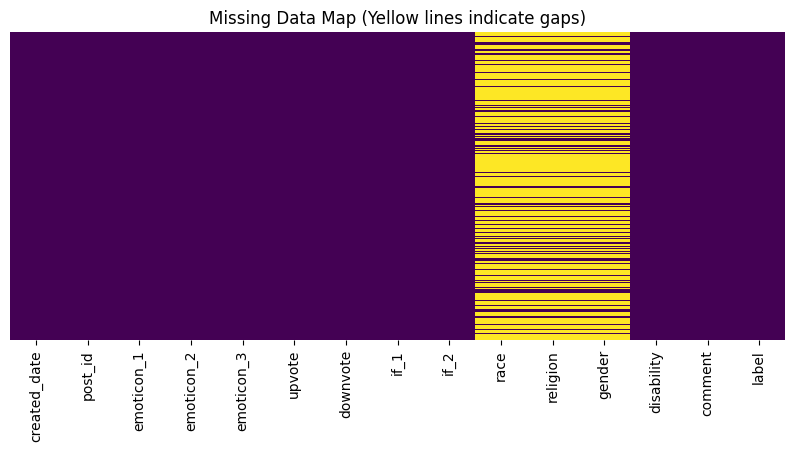

In [16]:
# Visualizing missing data in train dataset
plt.figure(figsize=(10, 4))
sns.heatmap(data.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Map (Yellow lines indicate gaps)")
plt.show()

In [17]:
print("missing values in train dataset")
print(data.isna().sum())
print("*-"*50)

missing values in train dataset
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-


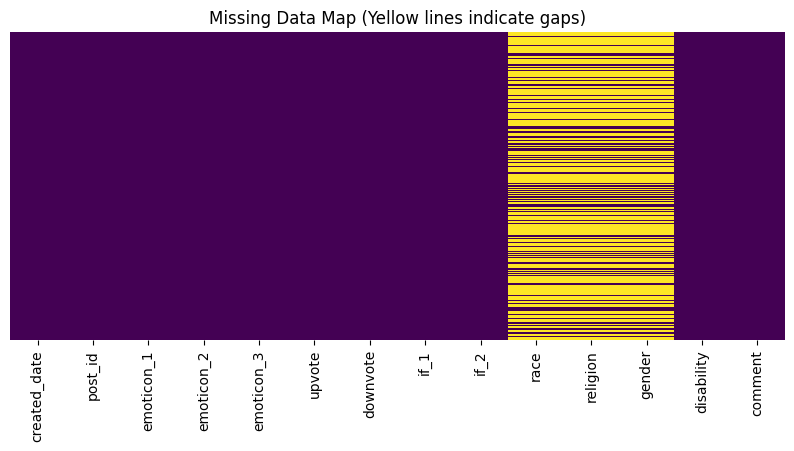

In [18]:
# Visualizing missing data in test datset
plt.figure(figsize=(10, 4))
sns.heatmap(test.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Map (Yellow lines indicate gaps)")
plt.show()

In [19]:
#percantage of nan values present in train data
print("total missing values preset in train datset in all column 'race', religion and gender is :",145423)
print("total percentage : ",(145423/198000)*100, "%")
print("-"*100)
#percantage of nan values present in test data
print("Total missing values are present in the test datset in all column 'race', 'religion' and 'gender' is :", 75269)
print("total percentage : ",(75269/102000)*100, "%")

total missing values preset in train datset in all column 'race', religion and gender is : 145423
total percentage :  73.4459595959596 %
----------------------------------------------------------------------------------------------------
Total missing values are present in the test datset in all column 'race', 'religion' and 'gender' is : 75269
total percentage :  73.79313725490196 %


*As a general rule of thumb, a column with over 50-70% missing data is a strong candidate for removal because there is not enough information to make reliable imputations, and keeping it may introduce bias or reduce model performance*

In [20]:
#dropping the columns contain the more than 70% nan values 
threshold = 0.7 * len(data)
new_data=data.dropna(axis=1, thresh=threshold).copy()
print("doppped successfully")
print("="*100)
print()
threshold = 0.5 * len(test)
new_test=test.dropna(axis=1, thresh=threshold).copy()
print("dropped successfully")
new_data.head()

doppped successfully

dropped successfully


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,False,"Today, the confederate flag...tomorrow, the na...",2


In [21]:
new_data["comment"].fillna("", inplace=True)

/tmp/ipykernel_17/1856230495.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_data["comment"].fillna("", inplace=True)


In [22]:
new_test["comment"].fillna("", inplace=True)

/tmp/ipykernel_17/3060491808.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_test["comment"].fillna("", inplace=True)


*checking for the duplicate values present in the dataset*

In [23]:
print(new_data.duplicated().sum())
print(new_test.duplicated().sum())

0
0


In [24]:
new_data["label"].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [25]:
def add_features_df(df):

    import numpy as np
    import pandas as pd

    # =========================
    # TEXT FEATURES
    # =========================
    txt = df['comment'].fillna('').astype(str)

    df['word_len'] = txt.str.split().str.len().astype(int)

    char_len = txt.str.len()
    df['avg_word_len'] = char_len / (df['word_len'] + 1)

    df['has_newline'] = txt.str.contains(r'\n').astype(int)
    df['has_question'] = txt.str.contains(r'\?').astype(int)

    # =========================
    # TIME FEATURES (Cyclical)
    # =========================
    dt = pd.to_datetime(df['created_date'], errors='coerce', utc=True)

    hour = dt.dt.hour.fillna(0)
    dow = dt.dt.dayofweek.fillna(0)

    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

    df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['dow_cos'] = np.cos(2 * np.pi * dow / 7)

    # =========================
    # VOTE FEATURES
    # =========================
    df['upvote_log1p'] = np.log1p(df['upvote'])
    df['downvote_log1p'] = np.log1p(df['downvote'])

    df['engagement_score'] = (
        df['upvote_log1p'] - df['downvote_log1p']
    )

    # =========================
    # EMOTION FEATURES
    # =========================
    df['emotion_density'] = (
        (df['emoticon_1'] +
         df['emoticon_2'] +
         df['emoticon_3'])
        / (df['word_len'] + 1)
    )

    df['emotion_engagement'] = (
        df['emotion_density'] * df['engagement_score']
    )

    # =========================
    # OTHER NUMERIC
    # =========================
    df['disability'] = df['disability'].astype(int)

    # =========================
    # DROP RAW COLUMNS
    # =========================
    df.drop(columns=[
        'created_date',
        'upvote',
        'downvote',
        'post_id',
        'emoticon_2'
    ], inplace=True)

    return df

**Identifying the outleires in datset**

In [26]:
new_data = add_features_df(new_data)
new_test= add_features_df(new_test)

In [27]:
new_data.head()

,emoticon_1,emoticon_3,if_1,if_2,disability,comment,label,word_len,avg_word_len,has_newline,has_question,hour_sin,hour_cos,dow_sin,dow_cos,upvote_log1p,downvote_log1p,engagement_score,emotion_density,emotion_engagement
0,0,0,0,10,0,She might be a bright spot for a party keou on...,2,20,5.619048,0,0,0.866025,-0.500000,0.433884,-0.900969,0.000000,0.693147,-0.693147,0.000000,-0.0
1,0,0,0,4,0,"Under Alaska law, a non-tribal member is not b...",0,110,5.801802,1,0,-0.707107,0.707107,-0.781831,0.623490,1.945910,0.000000,1.945910,0.000000,0.0
2,0,1,0,10,0,in the future please spare me your strawman dr...,2,133,5.604478,0,0,-0.866025,0.500000,0.974928,-0.222521,0.000000,0.000000,0.000000,0.014925,0.0
3,0,0,0,10,0,"PS: That should have been ""rot"" instead of ""co...",2,15,5.687500,0,0,-0.500000,0.866025,-0.781831,0.623490,1.791759,0.000000,1.791759,0.000000,0.0
4,0,0,0,10,0,"Today, the confederate flag...tomorrow, the na...",2,40,6.195122,0,0,-0.258819,0.965926,-0.974928,-0.222521,0.000000,0.000000,0.000000,0.000000,0.0


In [28]:
new_test.head()

,emoticon_1,emoticon_3,if_1,if_2,disability,comment,word_len,avg_word_len,has_newline,has_question,hour_sin,hour_cos,dow_sin,dow_cos,upvote_log1p,downvote_log1p,engagement_score,emotion_density,emotion_engagement
0,2,0,0,10,0,Canada is being run by someone with the mental...,12,5.538462,0,0,-0.258819,-0.965926,0.433884,-0.900969,1.609438,0.693147,0.916291,0.153846,0.140968
1,0,0,0,10,0,And your comment is left-wing drivel,6,5.142857,0,0,-0.258819,0.965926,-0.433884,-0.900969,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,0,0,4,0,http://talkingpointsmemo..com/dc/special-couns...,1,34.500000,0,0,-0.707107,0.707107,-0.433884,-0.900969,1.386294,0.000000,1.386294,0.000000,0.000000
3,0,0,0,4,0,"Trump jl Blames: The Secret Service, James Com...",23,6.458333,0,0,0.707107,0.707107,-0.974928,-0.222521,0.000000,0.000000,0.000000,0.000000,0.000000
4,0,0,0,11,0,It was hard enough to get the stench out of th...,17,4.277778,0,0,0.500000,0.866025,0.974928,-0.222521,0.000000,0.000000,0.000000,0.000000,0.000000


In [29]:
num_cols = new_data.select_dtypes(include=["int64", "float64"]).columns
print(num_cols)
print("="*100)
num_cols1=['emoticon_1', 'emoticon_3', 'if_1', 'if_2','word_len', 'avg_word_len', 'has_newline', 'has_question', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'upvote_log1p', 'downvote_log1p',
       'engagement_score', 'emotion_density', 'emotion_engagement']
for col in num_cols1:
    if col in new_data.columns:
        Q1 = new_data[col].quantile(0.25)
        Q3 = new_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = new_data[(new_data[col] < lower_bound) | (new_data[col] > upper_bound)]
        print(f"column '{col}': {len(outliers)} outliers detected.")
    else:
        print(f"column '{col}' not found in training data.")

# identifying the outlier in the train dataset
print("="*100)
print("for the test datset")
for col in num_cols1:
    if col in new_test.columns:
        Q1 = new_test[col].quantile(0.25)
        Q3 = new_test[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = new_test[(new_test[col] < lower_bound) | (new_test[col] > upper_bound)]
        print(f"column '{col}': {len(outliers)} outliers detected.")
    else:
        print(f"column '{col}' not found in test data.")

Index(['emoticon_1', 'emoticon_3', 'if_1', 'if_2', 'disability', 'label',
       'word_len', 'avg_word_len', 'has_newline', 'has_question', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'upvote_log1p', 'downvote_log1p',
       'engagement_score', 'emotion_density', 'emotion_engagement'],
      dtype='object')
column 'emoticon_1': 28922 outliers detected.
column 'emoticon_3': 17165 outliers detected.
column 'if_1': 85 outliers detected.
column 'if_2': 3930 outliers detected.
column 'word_len': 11131 outliers detected.
column 'avg_word_len': 9530 outliers detected.
column 'has_newline': 37931 outliers detected.
column 'has_question': 0 outliers detected.
column 'hour_sin': 0 outliers detected.
column 'hour_cos': 0 outliers detected.
column 'dow_sin': 0 outliers detected.
column 'dow_cos': 0 outliers detected.
column 'upvote_log1p': 915 outliers detected.
column 'downvote_log1p': 6621 outliers detected.
column 'engagement_score': 3181 outliers detected.
column 'emotion_density': 44

In [30]:
import numpy as np

print("Handling Outliers for Training Data")

bounds_dict = {}  # store train bounds

for col in num_cols1:
    if col in new_data.columns:
        
        lower_bound = new_data[col].quantile(0.05)
        upper_bound = new_data[col].quantile(0.95)

        bounds_dict[col] = (lower_bound, upper_bound)  # save bounds
        
        capped_count = ((new_data[col] < lower_bound) | 
                        (new_data[col] > upper_bound)).sum()

        new_data[col] = np.clip(new_data[col], lower_bound, upper_bound)

        print(f"Column '{col}': {capped_count} values capped in train.")
    else:
        print(f"Column '{col}' not found in training data.")

print("="*100)
print("Handling Outliers for Test Data")

for col in num_cols1:
    if col in new_test.columns and col in bounds_dict:

        lower_bound, upper_bound = bounds_dict[col]  # use train bounds

        capped_count = ((new_test[col] < lower_bound) | 
                        (new_test[col] > upper_bound)).sum()

        new_test[col] = np.clip(new_test[col], lower_bound, upper_bound)

        print(f"Column '{col}': {capped_count} values capped in test.")
    else:
        print(f"Column '{col}' not found in test data.")

Handling Outliers for Training Data
Column 'emoticon_1': 5440 values capped in train.
Column 'emoticon_3': 4148 values capped in train.
Column 'if_1': 85 values capped in train.
Column 'if_2': 4268 values capped in train.
Column 'word_len': 17853 values capped in train.
Column 'avg_word_len': 19701 values capped in train.
Column 'has_newline': 0 values capped in train.
Column 'has_question': 0 values capped in train.
Column 'hour_sin': 7926 values capped in train.
Column 'hour_cos': 7521 values capped in train.
Column 'dow_sin': 0 values capped in train.
Column 'dow_cos': 0 values capped in train.
Column 'upvote_log1p': 9874 values capped in train.
Column 'downvote_log1p': 9743 values capped in train.
Column 'engagement_score': 15533 values capped in train.
Column 'emotion_density': 9701 values capped in train.
Column 'emotion_engagement': 17878 values capped in train.
Handling Outliers for Test Data
Column 'emoticon_1': 2860 values capped in test.
Column 'emoticon_3': 2027 values capp

## Data visualization on the train and test dataset

In [31]:
new_test.head()

,emoticon_1,emoticon_3,if_1,if_2,disability,comment,word_len,avg_word_len,has_newline,has_question,hour_sin,hour_cos,dow_sin,dow_cos,upvote_log1p,downvote_log1p,engagement_score,emotion_density,emotion_engagement
0,2,0,0,10,0,Canada is being run by someone with the mental...,12,5.538462,0,0,-0.258819,-0.866025,0.433884,-0.900969,1.609438,0.693147,0.916291,0.117647,0.065935
1,0,0,0,10,0,And your comment is left-wing drivel,6,5.142857,0,0,-0.258819,0.965926,-0.433884,-0.900969,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,0,0,4,0,http://talkingpointsmemo..com/dc/special-couns...,6,6.531915,0,0,-0.707107,0.707107,-0.433884,-0.900969,1.386294,0.000000,1.386294,0.000000,0.000000
3,0,0,0,4,0,"Trump jl Blames: The Secret Service, James Com...",23,6.458333,0,0,0.707107,0.707107,-0.974928,-0.222521,0.000000,0.000000,0.000000,0.000000,0.000000
4,0,0,0,10,0,It was hard enough to get the stench out of th...,17,4.428571,0,0,0.500000,0.866025,0.974928,-0.222521,0.000000,0.000000,0.000000,0.000000,0.000000


In [32]:
new_data.head()

,emoticon_1,emoticon_3,if_1,if_2,disability,comment,label,word_len,avg_word_len,has_newline,has_question,hour_sin,hour_cos,dow_sin,dow_cos,upvote_log1p,downvote_log1p,engagement_score,emotion_density,emotion_engagement
0,0,0,0,10,0,She might be a bright spot for a party keou on...,2,20,5.619048,0,0,0.866025,-0.500000,0.433884,-0.900969,0.000000,0.693147,-0.693147,0.000000,-0.0
1,0,0,0,4,0,"Under Alaska law, a non-tribal member is not b...",0,110,5.801802,1,0,-0.707107,0.707107,-0.781831,0.623490,1.945910,0.000000,1.945910,0.000000,0.0
2,0,1,0,10,0,in the future please spare me your strawman dr...,2,133,5.604478,0,0,-0.866025,0.500000,0.974928,-0.222521,0.000000,0.000000,0.000000,0.014925,0.0
3,0,0,0,10,0,"PS: That should have been ""rot"" instead of ""co...",2,15,5.687500,0,0,-0.500000,0.866025,-0.781831,0.623490,1.791759,0.000000,1.791759,0.000000,0.0
4,0,0,0,10,0,"Today, the confederate flag...tomorrow, the na...",2,40,6.195122,0,0,-0.258819,0.965926,-0.974928,-0.222521,0.000000,0.000000,0.000000,0.000000,0.0


**visualising the classes of the Target columns to check class imbance**

Index([0, 2, 1, 3], dtype='int64', name='label')


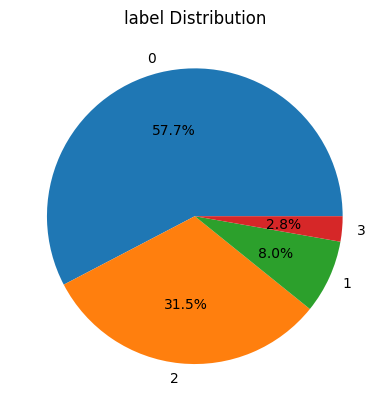

In [33]:
#check for class imbalance.
from matplotlib import pyplot as plt

counts = new_data["label"].value_counts()
print(counts.index)
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("label Distribution")
plt.show()

checking the correlation between the all the columns with the target  columns

In [34]:
new_data["disability"] = new_data["disability"].astype(int)
new_test["disability"] = new_test["disability"].astype(int)


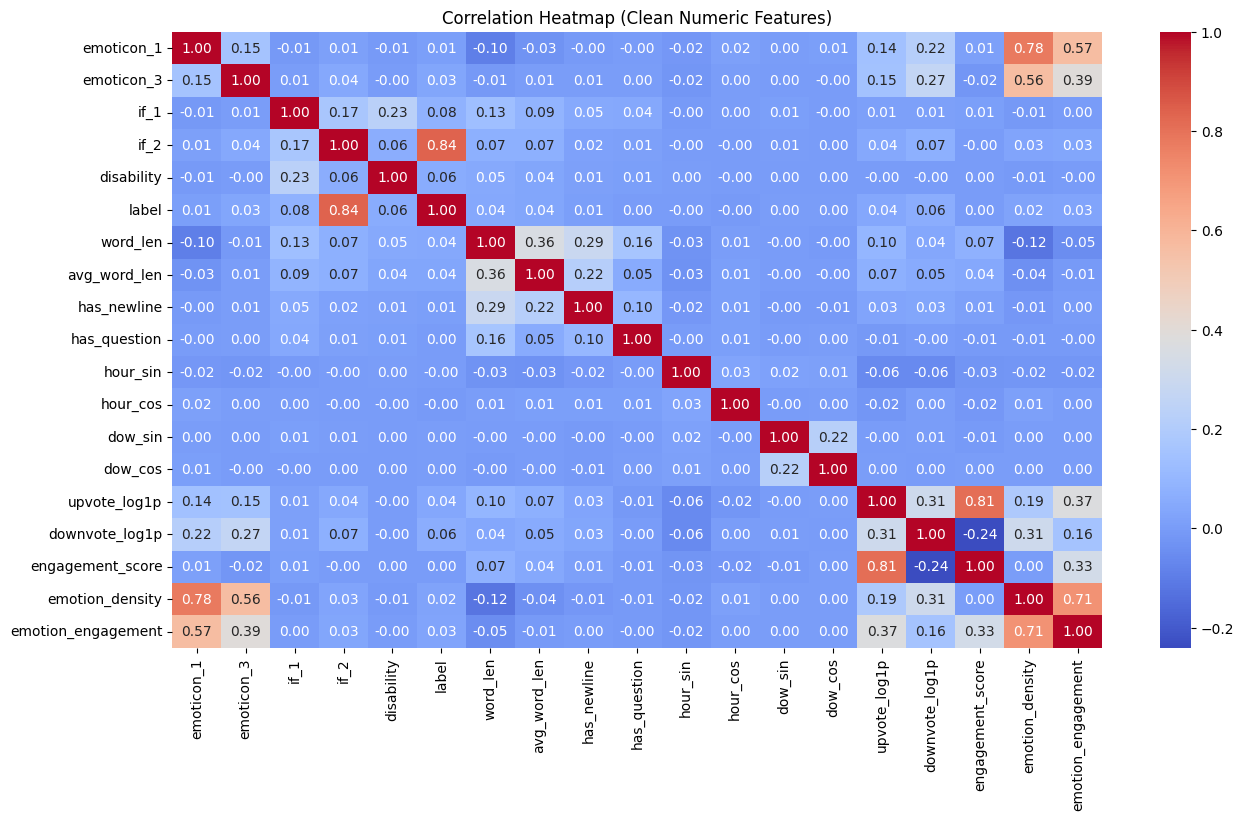

In [35]:
numeric_data = new_data.select_dtypes(include=[np.number])

# Remove ID + constant columns
numeric_data = numeric_data.drop(columns=['post_id'], errors='ignore')
numeric_data = numeric_data.loc[:, numeric_data.nunique() > 1]

plt.figure(figsize=(15, 8))
sns.heatmap(
    numeric_data.corr(method='spearman'),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap (Clean Numeric Features)")
plt.show()

In [36]:
# print(new_data.select_dtypes(include='number').corr(method='spearman'))

In [37]:
print(new_data.groupby('label')['if_2'].describe())

          count      mean       std  min   25%   50%   75%   max
label                                                           
0      114173.0  4.589693  1.424171  4.0   4.0   4.0   4.0  10.0
1       15918.0  9.937052  0.557828  4.0  10.0  10.0  10.0  10.0
2       62440.0  9.658728  1.285361  4.0  10.0  10.0  10.0  10.0
3        5469.0  9.841470  0.890652  4.0  10.0  10.0  10.0  10.0


***wordcloud to understand the most common words in  all the classes inn label***

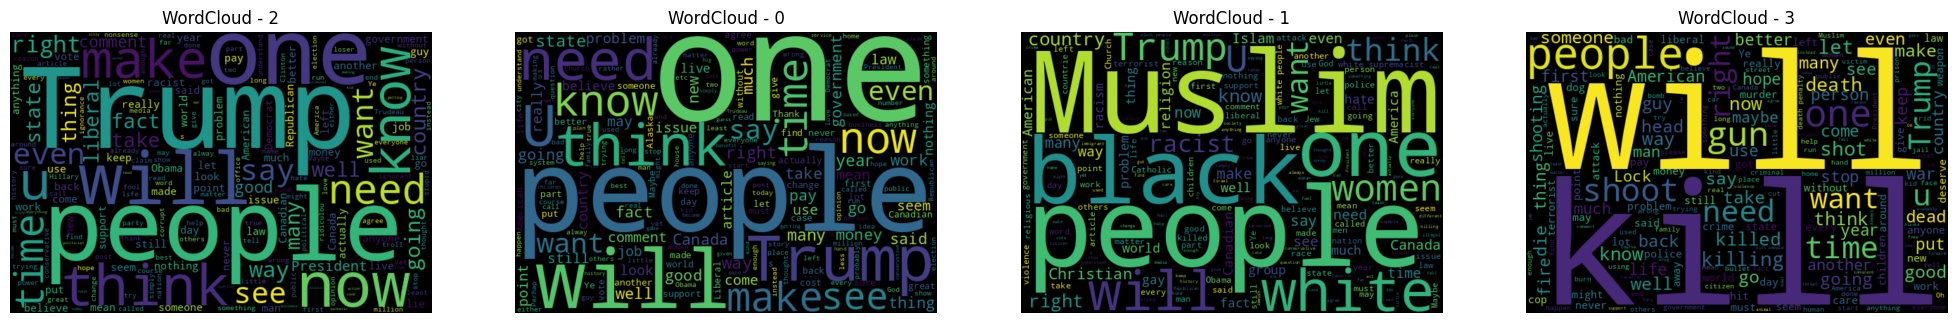

In [38]:
label = data["label"].unique()

plt.figure(figsize=(25,15))
for i, s in enumerate(label):
    text = " ".join(data[data.label == s]["comment"].astype(str))

    wc = WordCloud(width=600, height=400, background_color='black',
                   stopwords=STOPWORDS).generate(text)
    
    plt.subplot(1, len(label), i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud - {s}")


plt.show()

## preprocessing train and test data

In [39]:
labels=new_data["label"]
features=new_data.drop(["label"], axis=1)
# features=new_data.drop(["label","if_2" ], axis=1)

In [40]:
labels.head()

0    2
1    0
2    2
3    2
4    2
Name: label, dtype: int64

In [41]:
features["comment"] = features["comment"].astype(str)
new_test["comment"] = new_test["comment"].astype(str)

In [42]:
new_test.head()

,emoticon_1,emoticon_3,if_1,if_2,disability,comment,word_len,avg_word_len,has_newline,has_question,hour_sin,hour_cos,dow_sin,dow_cos,upvote_log1p,downvote_log1p,engagement_score,emotion_density,emotion_engagement
0,2,0,0,10,0,Canada is being run by someone with the mental...,12,5.538462,0,0,-0.258819,-0.866025,0.433884,-0.900969,1.609438,0.693147,0.916291,0.117647,0.065935
1,0,0,0,10,0,And your comment is left-wing drivel,6,5.142857,0,0,-0.258819,0.965926,-0.433884,-0.900969,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,0,0,4,0,http://talkingpointsmemo..com/dc/special-couns...,6,6.531915,0,0,-0.707107,0.707107,-0.433884,-0.900969,1.386294,0.000000,1.386294,0.000000,0.000000
3,0,0,0,4,0,"Trump jl Blames: The Secret Service, James Com...",23,6.458333,0,0,0.707107,0.707107,-0.974928,-0.222521,0.000000,0.000000,0.000000,0.000000,0.000000
4,0,0,0,10,0,It was hard enough to get the stench out of th...,17,4.428571,0,0,0.500000,0.866025,0.974928,-0.222521,0.000000,0.000000,0.000000,0.000000,0.000000


In [43]:
features.isna().sum()

emoticon_1            0
emoticon_3            0
if_1                  0
if_2                  0
disability            0
comment               0
word_len              0
avg_word_len          0
has_newline           0
has_question          0
hour_sin              0
hour_cos              0
dow_sin               0
dow_cos               0
upvote_log1p          0
downvote_log1p        0
engagement_score      0
emotion_density       0
emotion_engagement    0
dtype: int64

In [44]:
features.shape

(198000, 19)

In [45]:
new_test.isna().sum()

emoticon_1            0
emoticon_3            0
if_1                  0
if_2                  0
disability            0
comment               0
word_len              0
avg_word_len          0
has_newline           0
has_question          0
hour_sin              0
hour_cos              0
dow_sin               0
dow_cos               0
upvote_log1p          0
downvote_log1p        0
engagement_score      0
emotion_density       0
emotion_engagement    0
dtype: int64

In [46]:
import re
def clean_text(t):
    t = t.lower()
    t = re.sub(r"http\S+|www\S+", "", t)
    t = re.sub(r"[^a-z\s]", "", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

In [47]:
features["comment"] = features["comment"].apply(clean_text)
new_test["comment"] = new_test["comment"].apply(clean_text)


In [48]:
features["comment"]

0         she might be a bright spot for a party keou on...
1         under alaska law a nontribal member is not bou...
2         in the future please spare me your strawman dr...
3         ps that should have been rot instead of corrup...
4         today the confederate flagtomorrow the nazi fl...
                                ...                        
197995    why save people who are bent on selfdestructio...
197996    trudeau is not only undemocratic but also innu...
197997    block all exports no humanitarian relief and a...
197998    really black kids seeing that is better than g...
197999    sounds likely since but now scientists have fo...
Name: comment, Length: 198000, dtype: object

In [49]:
features.head()

,emoticon_1,emoticon_3,if_1,if_2,disability,comment,word_len,avg_word_len,has_newline,has_question,hour_sin,hour_cos,dow_sin,dow_cos,upvote_log1p,downvote_log1p,engagement_score,emotion_density,emotion_engagement
0,0,0,0,10,0,she might be a bright spot for a party keou on...,20,5.619048,0,0,0.866025,-0.500000,0.433884,-0.900969,0.000000,0.693147,-0.693147,0.000000,-0.0
1,0,0,0,4,0,under alaska law a nontribal member is not bou...,110,5.801802,1,0,-0.707107,0.707107,-0.781831,0.623490,1.945910,0.000000,1.945910,0.000000,0.0
2,0,1,0,10,0,in the future please spare me your strawman dr...,133,5.604478,0,0,-0.866025,0.500000,0.974928,-0.222521,0.000000,0.000000,0.000000,0.014925,0.0
3,0,0,0,10,0,ps that should have been rot instead of corrup...,15,5.687500,0,0,-0.500000,0.866025,-0.781831,0.623490,1.791759,0.000000,1.791759,0.000000,0.0
4,0,0,0,10,0,today the confederate flagtomorrow the nazi fl...,40,6.195122,0,0,-0.258819,0.965926,-0.974928,-0.222521,0.000000,0.000000,0.000000,0.000000,0.0


In [50]:
x_train, x_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=42, stratify=labels)

In [51]:
x_train.isnull().sum()

emoticon_1            0
emoticon_3            0
if_1                  0
if_2                  0
disability            0
comment               0
word_len              0
avg_word_len          0
has_newline           0
has_question          0
hour_sin              0
hour_cos              0
dow_sin               0
dow_cos               0
upvote_log1p          0
downvote_log1p        0
engagement_score      0
emotion_density       0
emotion_engagement    0
dtype: int64

In [52]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158400 entries, 180416 to 141917
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   emoticon_1          158400 non-null  int64  
 1   emoticon_3          158400 non-null  int64  
 2   if_1                158400 non-null  int64  
 3   if_2                158400 non-null  int64  
 4   disability          158400 non-null  int64  
 5   comment             158400 non-null  object 
 6   word_len            158400 non-null  int64  
 7   avg_word_len        158400 non-null  float64
 8   has_newline         158400 non-null  int64  
 9   has_question        158400 non-null  int64  
 10  hour_sin            158400 non-null  float64
 11  hour_cos            158400 non-null  float64
 12  dow_sin             158400 non-null  float64
 13  dow_cos             158400 non-null  float64
 14  upvote_log1p        158400 non-null  float64
 15  downvote_log1p      158400 non-nul

In [53]:
num_cols = x_train.select_dtypes(include=["int64", "float64"]).columns

In [54]:
text_preprocessor = Pipeline([
    ("selector", FunctionTransformer(lambda x: x.astype(str), validate=False)),
    ("tfidf", TfidfVectorizer(lowercase=True, max_features=8000, stop_words="english", sublinear_tf=True))
])

# ColumnTransformer
ct = ColumnTransformer([
    ('term_freq', text_preprocessor, 'comment'),
    ('scale', MinMaxScaler(),num_cols)
], remainder='passthrough', verbose_feature_names_out=False)

In [55]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC 
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix,classification_report


models = {
    "LogisticRegression": LogisticRegression(max_iter=5000,class_weight="balanced", solver="saga"),
    "SGDclassfier": SGDClassifier(loss="log_loss", max_iter=5000),
    "SVM": LinearSVC(class_weight="balanced"),
    "NaiveBayes": ComplementNB(),
    "multnb" : MultinomialNB(),
    "lgbm" :LGBMClassifier(
    objective='multiclass',
    num_class=4,
    class_weight='balanced',
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
}

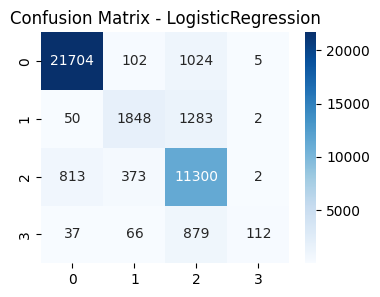

LogisticRegression Accuracy: 0.8829
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.77      0.58      0.66      3183
           2       0.78      0.90      0.84     12488
           3       0.93      0.10      0.18      1094

    accuracy                           0.88     39600
   macro avg       0.86      0.63      0.66     39600
weighted avg       0.89      0.88      0.87     39600

----------------------------------------------------------------------------------------------------


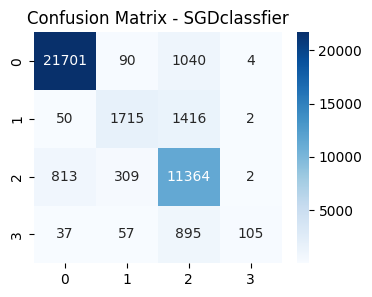

SGDclassfier Accuracy: 0.8809
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.79      0.54      0.64      3183
           2       0.77      0.91      0.84     12488
           3       0.93      0.10      0.17      1094

    accuracy                           0.88     39600
   macro avg       0.86      0.62      0.65     39600
weighted avg       0.89      0.88      0.87     39600

----------------------------------------------------------------------------------------------------


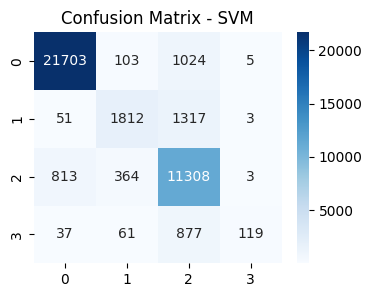

SVM Accuracy: 0.8824
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.77      0.57      0.66      3183
           2       0.78      0.91      0.84     12488
           3       0.92      0.11      0.19      1094

    accuracy                           0.88     39600
   macro avg       0.86      0.63      0.66     39600
weighted avg       0.89      0.88      0.87     39600

----------------------------------------------------------------------------------------------------


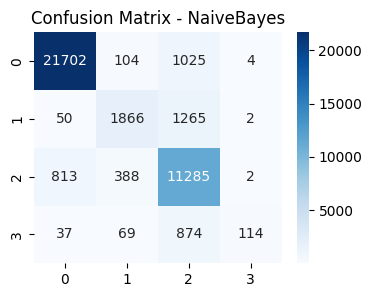

NaiveBayes Accuracy: 0.8830
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.77      0.59      0.67      3183
           2       0.78      0.90      0.84     12488
           3       0.93      0.10      0.19      1094

    accuracy                           0.88     39600
   macro avg       0.86      0.64      0.66     39600
weighted avg       0.89      0.88      0.87     39600

----------------------------------------------------------------------------------------------------


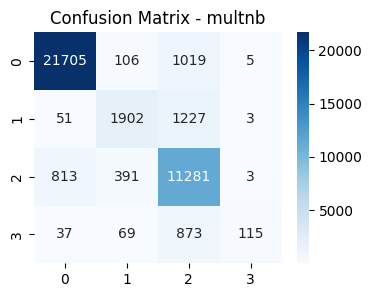

multnb Accuracy: 0.8839
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.77      0.60      0.67      3183
           2       0.78      0.90      0.84     12488
           3       0.91      0.11      0.19      1094

    accuracy                           0.88     39600
   macro avg       0.86      0.64      0.66     39600
weighted avg       0.89      0.88      0.87     39600

----------------------------------------------------------------------------------------------------


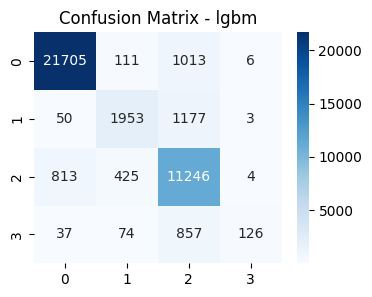

lgbm Accuracy: 0.8846
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.76      0.61      0.68      3183
           2       0.79      0.90      0.84     12488
           3       0.91      0.12      0.20      1094

    accuracy                           0.88     39600
   macro avg       0.85      0.64      0.67     39600
weighted avg       0.89      0.88      0.88     39600

----------------------------------------------------------------------------------------------------


In [56]:
results = {}
for name, model in models.items():
    pipe=Pipeline([
    ("preprocess", ct),
    ("model", SGDClassifier(loss="log_loss", max_iter=500))])
    pipe.fit(x_train, y_train)
    preds = pipe.predict(x_val)
    cm = confusion_matrix(y_val, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    acc=accuracy_score(y_val, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_val, preds))
    print("-" * 100)

In [57]:
results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
5,lgbm,0.884596
4,multnb,0.883914
3,NaiveBayes,0.883005
0,LogisticRegression,0.882929
2,SVM,0.882374
1,SGDclassfier,0.880934


## Hyperparameter tuning for the all  best models

In [58]:
# # hyperparamater tuning for the Sgd classifier
# from sklearn.model_selection import RandomizedSearchCV

# param_sgd1 = {
#     "preprocessor__term_freq__tfidf__max_df": (0.5, 0.75, 1.0),
#     "preprocessor__term_freq__tfidf__max_features": (None, 5000,7000, 8000, 10000),
#     "preprocessor__term_freq__tfidf__ngram_range": ((1, 1), (1, 2)),

#     'clf__alpha': [1e-5, 1e-4, 1e-3, 0.01, 0.1],
#     'clf__penalty': ['l2', 'l1', 'elasticnet'],
#     'clf__max_iter': (10, 50, 80),
#     'clf__learning_rate': ['optimal', 'adaptive', 'invscaling'],
#     'clf__eta0': [0.01, 0.1, 1.0],
#     'clf__class_weight': ['balanced', None] 
# }


# sgd_pipeline = Pipeline([
#     ('preprocessor', ct),
#     ('clf', SGDClassifier(
#         max_iter=2000, 
#         tol=1e-4, 
#         early_stopping=True, # Important for speed
#         n_jobs=-1,
#         random_state=42
#     ))
# ])

# print(sgd_pipeline.get_params().keys())

# random_search = RandomizedSearchCV(
#     sgd_pipeline,
#     param_distributions=param_sgd1,
#     n_iter=20,           # 20 random models
#     cv=3,                # 3-Fold Cross Validation
#     scoring='f1_weighted', # Optimize for F1 due to imbalance
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# import warnings
# warnings.filterwarnings('ignore')
# random_search.fit(features, labels)

# print(f"Best Score (F1): {random_search.best_score_:.4f}")
# print(f"Best Params: {random_search.best_params_}")

In [59]:
# best_pipe = random_search.best_estimator_

# pred = best_pipe.predict(x_val)
# print("Tuned holdout F1 macro:", f1_score(y_val, pred, average='macro'))
# print(classification_report(y_val, pred, digits=3))


In [60]:
# from xgboost import XGBClassifier
# from sklearn.model_selection import RandomizedSearchCV

# # 1. Initialize the XGBoost Classifier
# # 'tree_method="hist"' is essential for speed at 200k rows
# xgb_clf = XGBClassifier(
#     tree_method='hist', 
#     device="cpu",   
#     eval_metric='logloss',
#     random_state=42
# )

# # 2. Define the Search Space
# param_grid = {
#     'clf__n_estimators': [100, 300, 500],
#     'clf__learning_rate': [0.01, 0.05, 0.1],
#     'clf__max_depth': [3, 6, 9],
#     'clf__subsample': [0.8, 1.0],
#     'clf__colsample_bytree': [0.3, 0.5, 0.7],
#     'clf__gamma': [0, 0.1, 0.5],
    
#     # this one is fine IF your ColumnTransformer step is named 'text'
#     'preprocessor__term_freq__tfidf__max_features': [5000, 10000]
# }

# pipeline = Pipeline([
#     ('preprocessor', ct),
#     ('clf', xgb_clf)])

# # 3. Randomized Search
# xgb_search = RandomizedSearchCV(
#     pipeline, # The pipeline containing your preprocessor
#     param_distributions=param_grid,
#     n_iter=20, 
#     cv=3, 
#     scoring='f1_weighted',
#     n_jobs=-1, 
#     verbose=1
# )

# xgb_search.fit(features, labels)

In [61]:
# best_pipe = xgb_search.best_estimator_

# pred = best_pipe.predict(x_val)
# print("Tuned holdout F1 macro:", f1_score(y_val, pred, average='macro'))
# print(classification_report(y_val, pred, digits=3))


## Fine tuning Loght gbm 

In [62]:
# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# param_dist = {
#     # TF-IDF
#     'preprocessor__term_freq__tfidf__max_features': [15000, 20000, 30000],
#     'preprocessor__term_freq__tfidf__ngram_range': [(1,1), (1,2)],
#     'preprocessor__term_freq__tfidf__min_df': [3, 5, 10],
#     'preprocessor__term_freq__tfidf__max_df': [0.90, 0.95, 0.98],

#     # LightGBM
#     'clf__n_estimators': [800, 1200, 1600],
#     'clf__learning_rate': [0.03, 0.05, 0.07],
#     'clf__num_leaves': [63, 127, 255],
#     'clf__min_child_samples': [10, 20, 40, 80],
#     'clf__subsample': [0.7, 0.85, 1.0],
#     'clf__colsample_bytree': [0.7, 0.85, 1.0],
#     'clf__reg_alpha': [0.0, 0.1, 0.5],
#     'clf__reg_lambda': [0.0, 0.1, 0.5],
# }

# lgbm = LGBMClassifier(
#     objective='multiclass',
#     num_class=4,
#     class_weight='balanced',
#     n_estimators=1200,
#     learning_rate=0.05,
#     num_leaves=127,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1
# )

# pipeline = Pipeline([
#     ('preprocessor', ct),
#     ('clf', lgbm)
# ])

# rs = RandomizedSearchCV(
#     estimator=pipeline,   # <-- fixed
#     param_distributions=param_dist,
#     n_iter=12,
#     scoring='f1_macro',
#     cv=cv,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )

# rs.fit(features, labels)

# print("Best CV F1 macro:", rs.best_score_)
# print("Best params:", rs.best_params_)

In [63]:
# best_pipe = rs.best_estimator_

# pred = best_pipe.predict(x_val)
# print("Tuned holdout F1 macro:", f1_score(y_val, pred, average='macro'))
# print(classification_report(y_val, pred, digits=3))


### Final model

In [64]:
# best_pipe.fit(features, labels)


In [65]:
# y_preds = best_pipe.predict(new_test)

In [66]:
final_pipe = Pipeline([
    ("preprocess", ct),
    ("model", LGBMClassifier(
    objective='multiclass',
    num_class=4,
    class_weight='balanced',
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1))
])

final_pipe.fit(features,labels)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 8.908658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 770826
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 8018
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('term_freq',
                                                  Pipeline(steps=[('selector',
                                                                   FunctionTransformer(func=<function <lambda> at 0x7cb2ef922020>)),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=8000,
                                                                                   stop_words='english',
                                                                                   sublinear_tf=True))]),
                                                  'comment'),
                                                 ('scale', MinMaxScaler(),
                                                  Index(['emoticon_1', 'emoticon_3', 'if_1',...
       'dow_sin', 'dow_cos', 'upvote_log1p', 'downvote_log1p',
       'engagement_score', 'emotion_density', 'emotion_engagement'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('model',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
                                learning_rate=0.05, n_estimators=1200,
                                n_jobs=-1, num_class=4, num_leaves=127,
                                objective='multiclass', random_state=42,
                                subsample=0.8))])

In [67]:
y_preds = final_pipe.predict(new_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [68]:
submission = pd.DataFrame({"ID": range(1,new_test.shape[0]+1), "label": y_preds}) 
submission.head()

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


In [69]:
submission["label"].value_counts()

label
0    56820
2    33668
1     8727
3     2785
Name: count, dtype: int64

In [70]:
submission.shape

(102000, 2)

In [71]:

submission.to_csv('submission.csv', index=False)